In [1]:
# ananlyze atoh7 all cells
library(dplyr)
library(Seurat)
AA.data <- Read10X(data.dir = "./atoh7_matrix/")
# creat a seurat vector
AA <- CreateSeuratObject(counts = AA.data, project = "atoh7Progenitor", min.cells = 3, min.features = 200)
AA


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


An object of class Seurat 
18835 features across 3860 samples within 1 assay 
Active assay: RNA (18835 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”


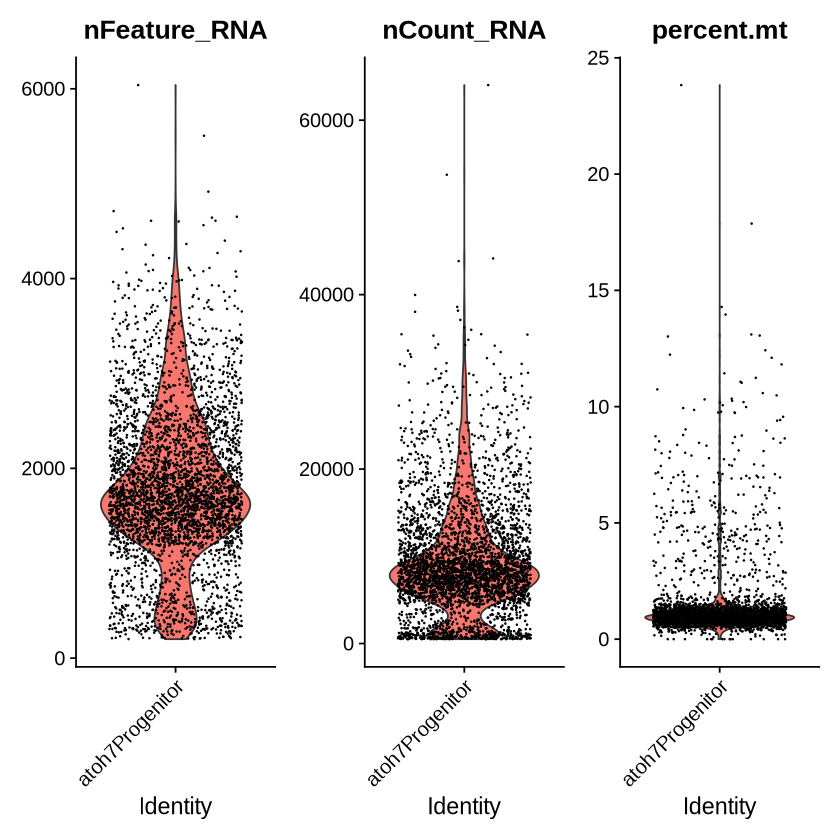

Normalizing layer: counts

Warning message:
“The following arguments are not used: scale.fprecursortor”
Finding variable features for layer counts

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


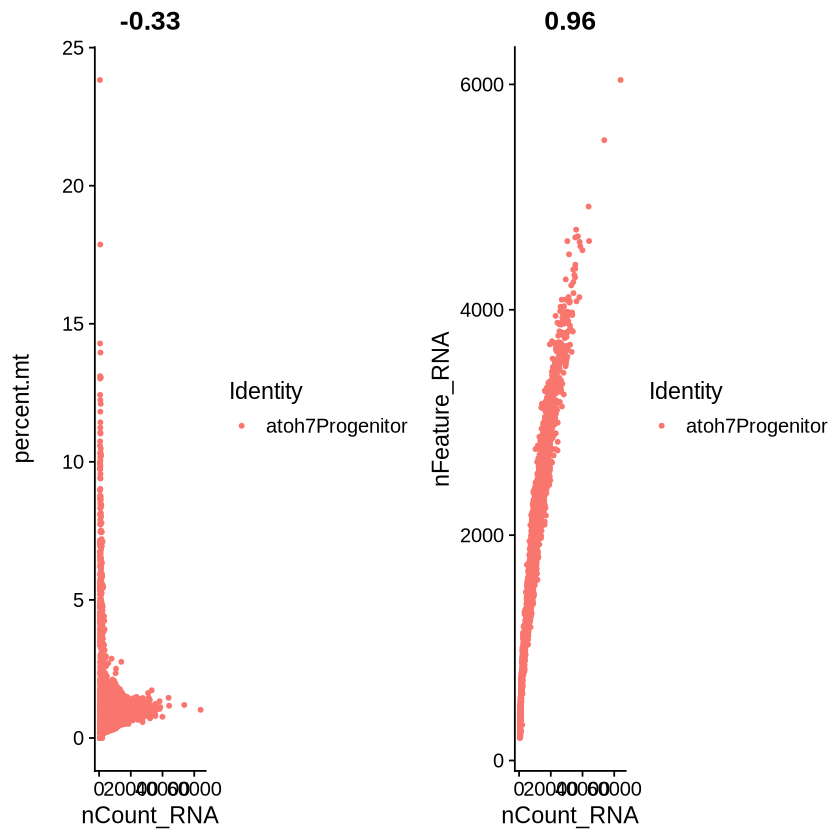

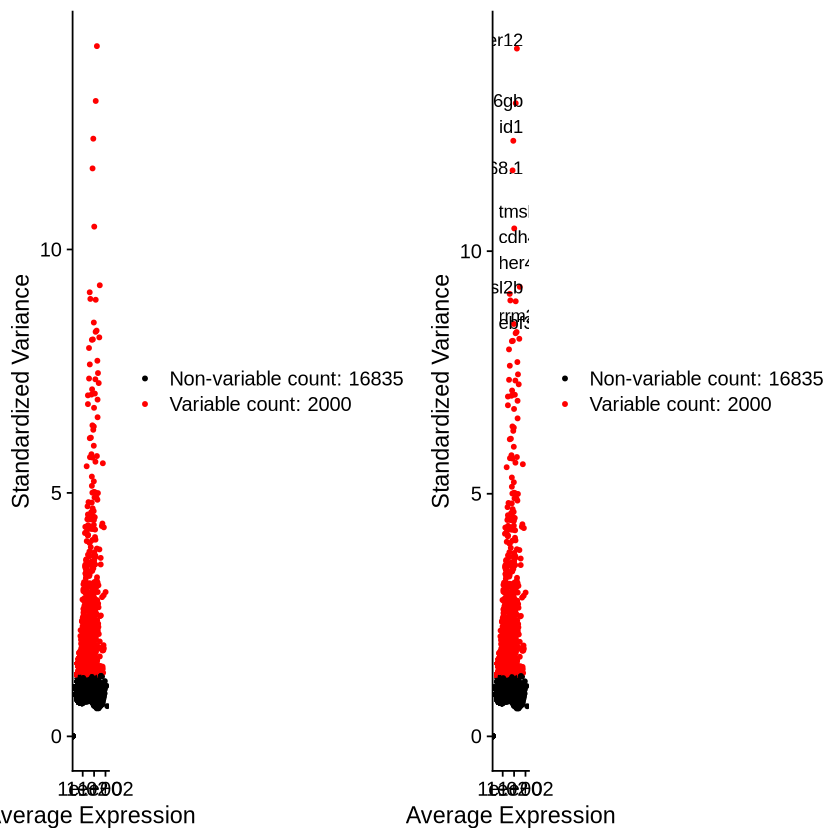

In [2]:
# standard pre-processing workflow
## filter cells with more than 5% mitochondrial counts, filter cells that have unique feature counts over 2,500 or less than 200 
AA[["percent.mt"]] <- PercentageFeatureSet(AA, pattern = "^mt-")
VlnPlot(AA, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
plot1 <- FeatureScatter(AA, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(AA, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
CombinePlots(plots = list(plot1, plot2))
AA<- subset(AA, subset = nFeature_RNA > 200 & nFeature_RNA < 2500 & percent.mt < 5)
## normalizing the data
AA <- NormalizeData(AA, normalization.method = "LogNormalize", scale.fprecursortor = 10000)
## Identification of highly variable features (feature selection)
AA<- FindVariableFeatures(AA, selection.method = "vst", nfeatures = 2000)
top10 <- head(VariableFeatures(AA), 10)
plot1 <- VariableFeaturePlot(AA)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
CombinePlots(plots = list(plot1, plot2))

In [3]:
all.genes <- rownames(AA)
AA <- ScaleData(AA, features = all.genes)
# linear dimention reduction
AA <- RunPCA(AA, features = VariableFeatures(object = AA))

Centering and scaling data matrix

PC_ 1 
Positive:  elavl3, rbpms2b, stmn2b, rtn1a, alcama, tmsb, gng3, islr2, tubb5, gap43 
	   zc4h2, rtn1b, ebf3a.1, mllt11, jagn1a, aplp1, scrt2, gdi1, zgc:153426, gng2 
	   rbfox2, ywhah, adcyap1b, zfhx3, fabp3, tuba2, fez1, rbpms2a, zgc:100920, pou6f2 
Negative:  hmgb2a, hmgn2, ccna2, lbr, mki67, si:ch73-281n10.2, mad2l1, nusap1, foxn4, hmgb2b 
	   cdk1, msna, rrm2.1, rrm1, anp32b, cks1b, top2a, tuba8l, aurkb, hmga1a 
	   zgc:165555.11, CABZ01058261.1, h3f3a, tpx2, plk1, dlgap5, ube2c, mibp, dek, kif22 
PC_ 2 
Positive:  tuba1c, islr2, tubb4b, rtn1b, gng3, rbpms2a, tmsb, stmn2b, tubb2b, pou6f2 
	   gap43, tuba1a, stmn1b, calm2b, actb1, tuba2, nusap1, rbpms2b, stmn2a, cdk1 
	   aplp1, top2a, kifc1, tpx2, mad2l1, alcama, CR847968.1, plk1, aurkb, adcyap1b 
Negative:  fabp7a, s1pr1, otx5, nop10, mdka, tfap2c, fkbp1ab, abhd6a, lfng, her15.2 
	   ppdpfa, crx, prdm13, ptf1a, ccng1, her15.1, hey1, si:ch211-207i1.2, npm1a, lzts2a 
	   slco5a1a.1, pde6gb, l

In [4]:
# cluster the cell
AA <- FindNeighbors(AA, dims = 1:12)
AA <- FindClusters(AA, resolution = 0.5)
# run non-linear dimentional reduction
AA <- RunUMAP(AA, dims = 1:12)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3046
Number of edges: 93330

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8885
Number of communities: 12
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
16:16:30 UMAP embedding parameters a = 0.9922 b = 1.112

16:16:30 Read 3046 rows and found 12 numeric columns

16:16:30 Using Annoy for neighbor search, n_neighbors = 30

16:16:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:16:30 Writing NN index file to temp file /tmp/RtmpmJ67V6/file4c48f6b6137b4

16:16:30 Searching Annoy index using 1 thread, search_k = 3000

16:16:31 Annoy recall = 100%

16:16:31 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors 

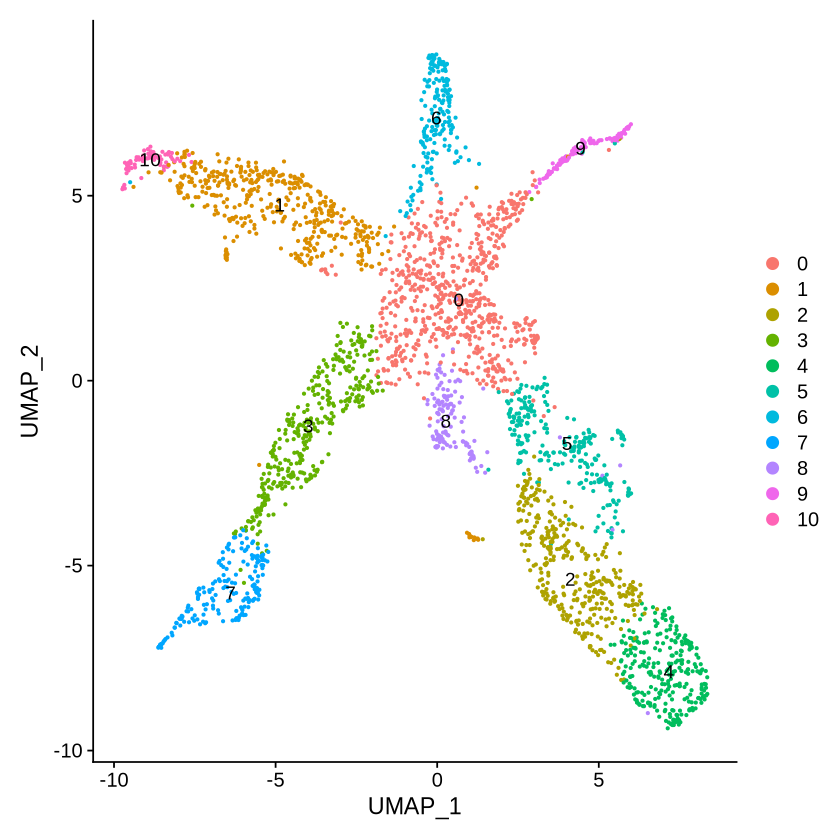

In [6]:
DimPlot(AA, reduction = "umap", label = T)

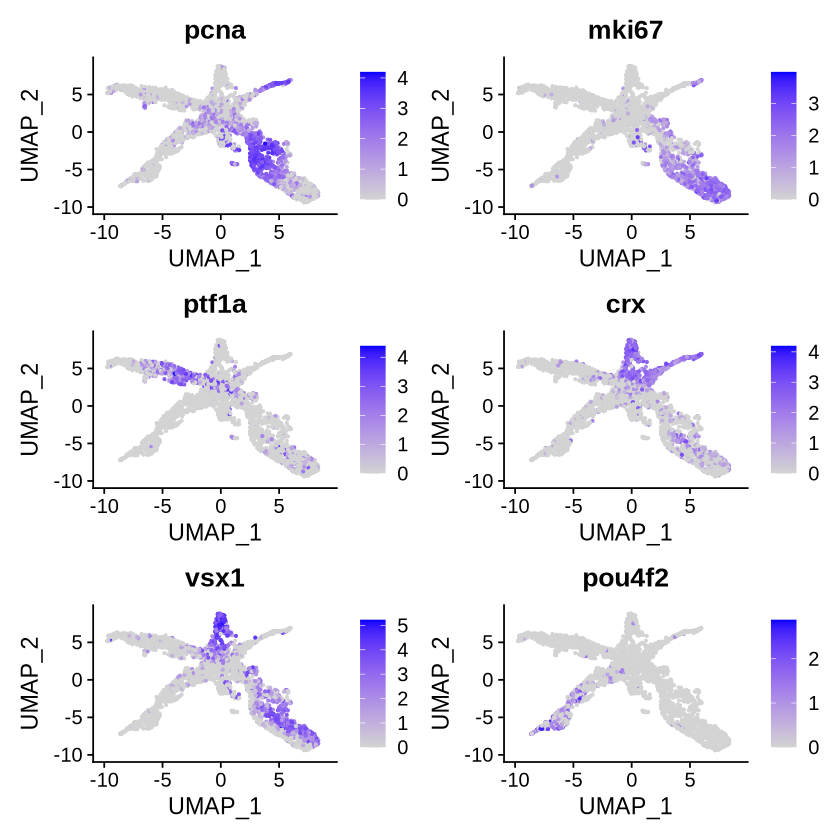

In [7]:
FeaturePlot(AA, features = c("pcna", "mki67","ptf1a", "crx",   "vsx1", "pou4f2"))

In [8]:
AA <- RenameIdents(AA, "0" = "pre", "1" = "AC", "2" = "pro", "3" = "RGC", "4" = "pro", "5" = "pro", "6" = "BC", "7" = "RGC", "8" = "unknown", "9" = "PR", "10" = "AC")

## replication of Figure S6A

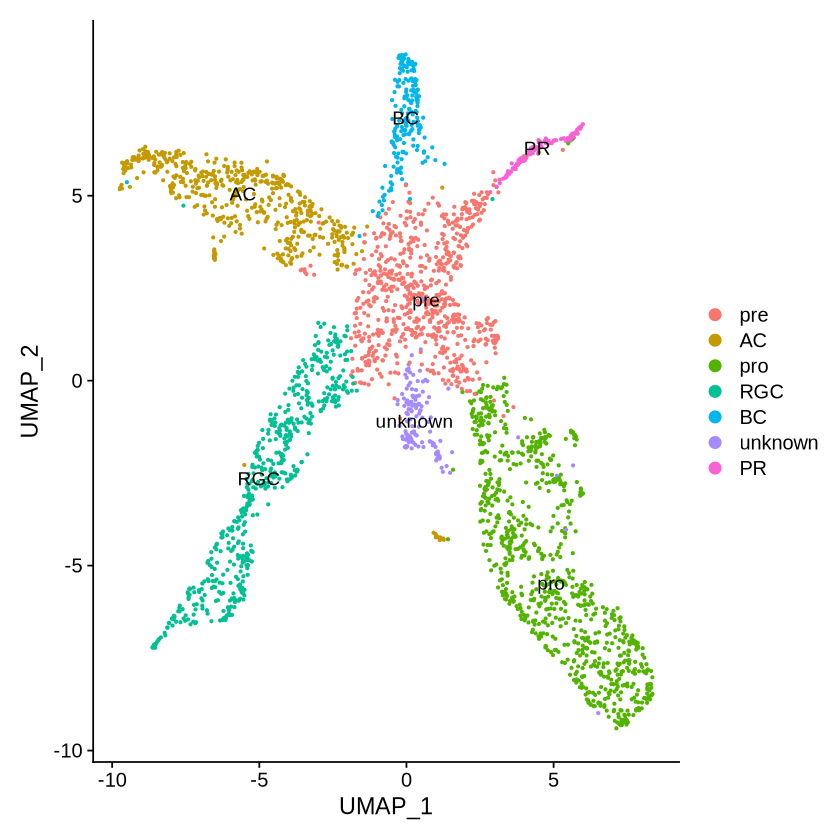

In [9]:
DimPlot(AA, reduction = "umap", label = T)

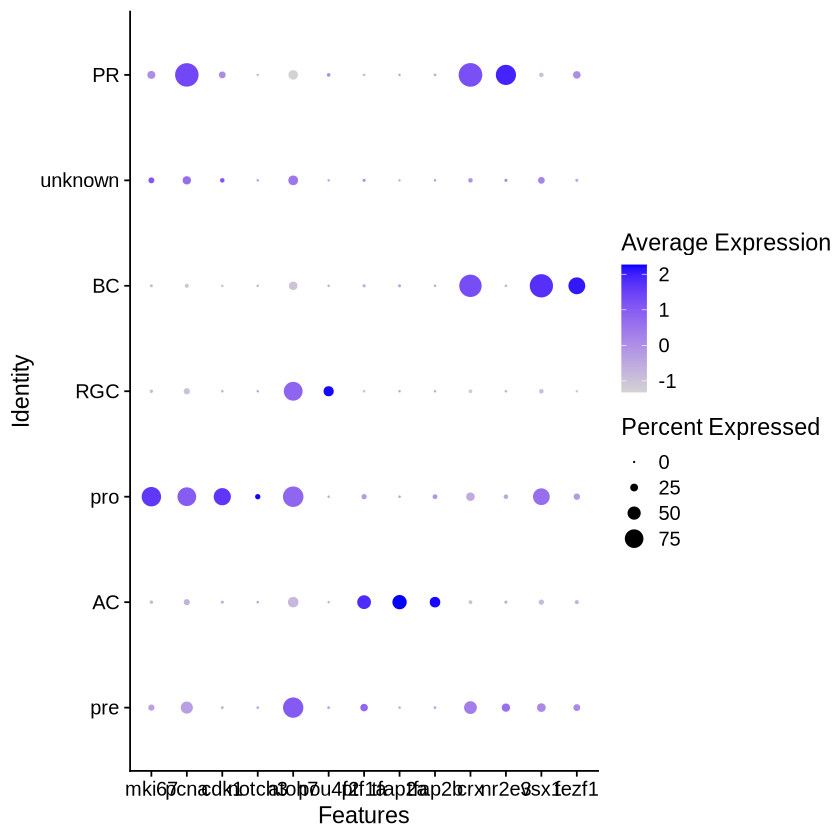

In [2]:
# check marker genes expression, replication of Figure S6B
DotPlot(AA, features = c("mki67", "pcna", "cdk1", "notch3", "atoh7", "pou4f2", "ptf1a", "tfap2a", "tfap2b", "crx", "nr2e3", "vsx1", "fezf1"))

# reanalyze pre

In [10]:
# reanalyze precursor cells
precursor <- subset(AA, idents = c ("pre"))
precursor <- NormalizeData(precursor)
precursor <- FindVariableFeatures(precursor, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(precursor)
precursor <- ScaleData(precursor, features = all.genes)
precursor <- RunPCA(precursor, features = VariableFeatures(object = precursor))
precursor <- FindNeighbors(precursor, dims = 1:10)
precursor <- FindClusters(precursor, resolution = 0.8)
precursor <- RunUMAP(precursor, dims = 1:10)

Centering and scaling data matrix

PC_ 1 
Positive:  hmgn2, ptmaa, hmgb1b, si:ch211-222l21.1, mdka, her4.2, her15.2, hmgb2a, her15.1, si:ch73-1a9.3 
	   her4.2.1, hmgb1a, abhd6a, si:ch73-281n10.2, atoh7, her4.1, tp53inp2, tubb4b, hnrnpa0b, actb1 
	   sinhcafl.1, her4.4, gpm6aa, dla, tuba8l4, im:7152348, si:ch73-215f7.1, msna, ptprua, olig2 
Negative:  pde6gb, otx5, msi1, nr2e3, ccnd1, dscamb, crx, ctnna2, magi3a, thrb 
	   rxrgb, lhx4, dscaml1, arid3b, gngt2a, pcdh11.1, gapdhs, RASSF5, robo3, greb1l 
	   tulp1a, npm1a, dock1, baz2ba, sema3aa, six7, draxin, fabp3, LO018148.1, prdm1a 
PC_ 2 
Positive:  hey1, atoh7, cdkn1cb, pax6b, her4.1, pax6a, cxcr4b, rpa3, pcna, si:busm1-57f23.1 
	   stmn1a, her2, adgrl3.1, barhl1a, her4.2.1, elmo1, elavl3, mllt11, dock1, rpa2 
	   rpa1, her4.2, rrm2.1, her12, onecut1, six6b, lig1, pbx1a, si:ch211-207i1.2, tox3 
Negative:  ndrg1b, crx, vsx1, neurod1, fezf1, fkbp1ab, gpm6ab, ckbb, mdka, otx5 
	   ptprua, lhx4, olig2, neurod4, sox4a.1, prickle1b, baz2ba

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 685
Number of edges: 23389

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6628
Number of communities: 5
Elapsed time: 0 seconds


16:18:04 UMAP embedding parameters a = 0.9922 b = 1.112

16:18:04 Read 685 rows and found 10 numeric columns

16:18:04 Using Annoy for neighbor search, n_neighbors = 30

16:18:04 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:18:04 Writing NN index file to temp file /tmp/RtmpmJ67V6/file4c48f2d503cfa

16:18:04 Searching Annoy index using 1 thread, search_k = 3000

16:18:04 Annoy recall = 100%

16:18:04 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:18:05 Initializing from normalized Laplacian + noise (using RSpectra)

16:18:05 Commencing optimization for 500 epochs, with 25178 positive edges

16:18:07 Optimization finished



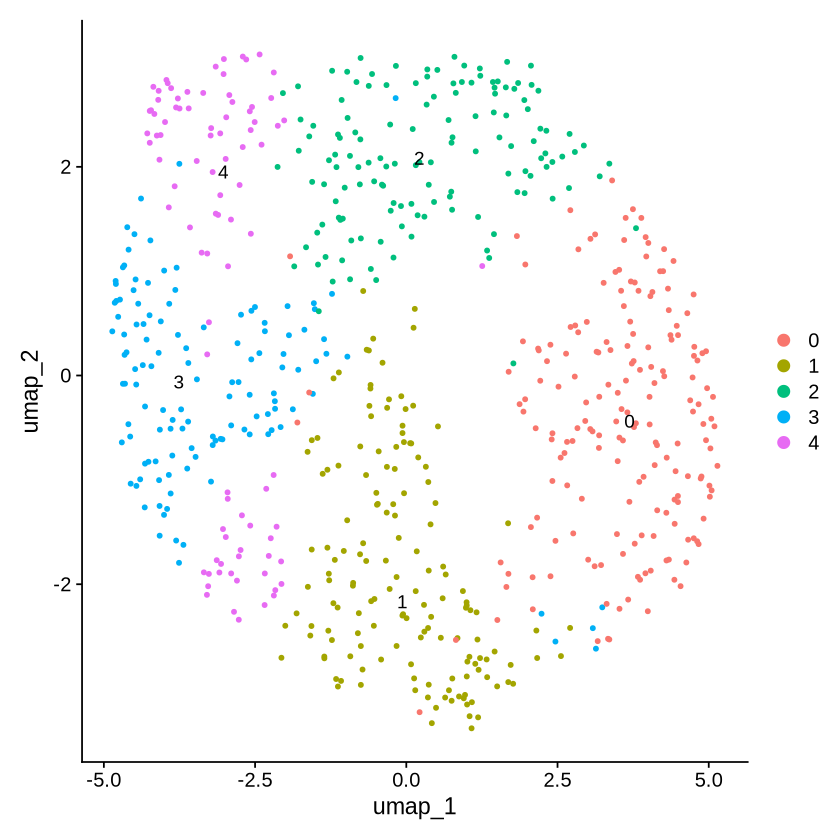

In [11]:
DimPlot(precursor, reduction = "umap", label = TRUE)

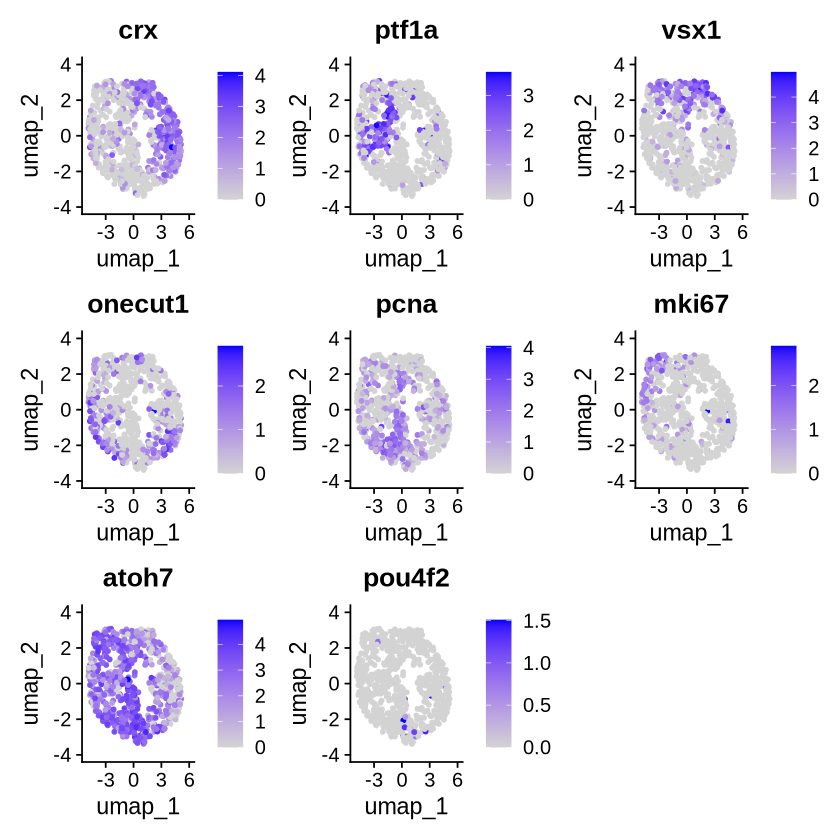

In [12]:
FeaturePlot(precursor, features = c("crx", "ptf1a", "vsx1", "onecut1", "pcna", "mki67", "atoh7", "pou4f2"))


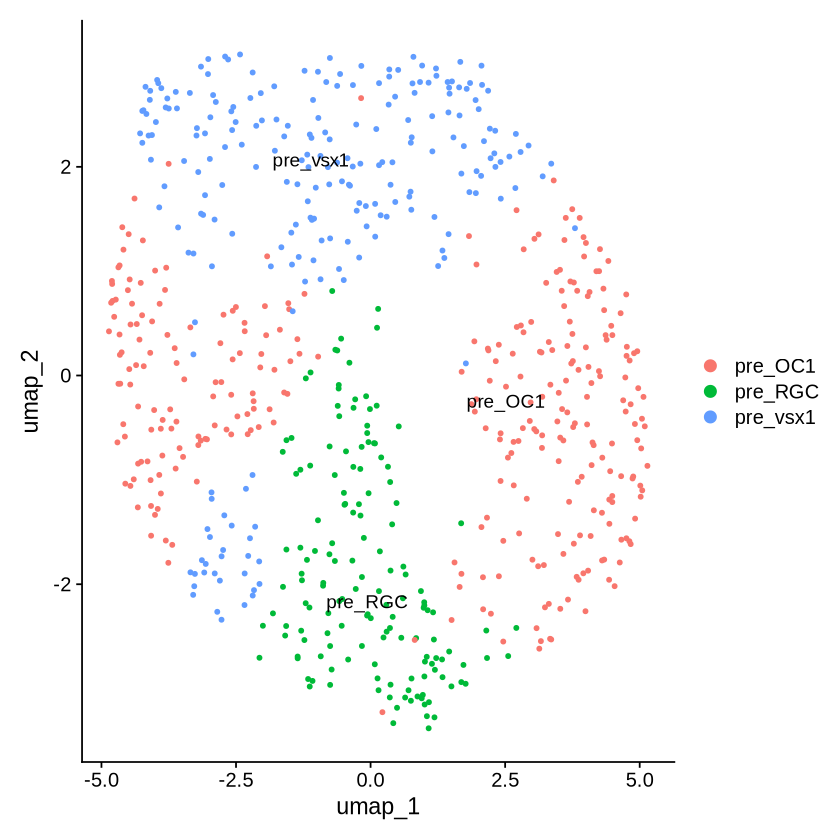

In [13]:
## annotate clusters
precursor <- RenameIdents(precursor, "0" = "pre_OC1", "1" = "pre_RGC", "2" = "pre_vsx1", "3" = "pre_OC1", "4" = "pre_vsx1")
DimPlot(precursor, reduction = "umap", label = TRUE)

## replication of Figure S6D

Warning message:
“Scaling data with a low number of groups may produce misleading results”


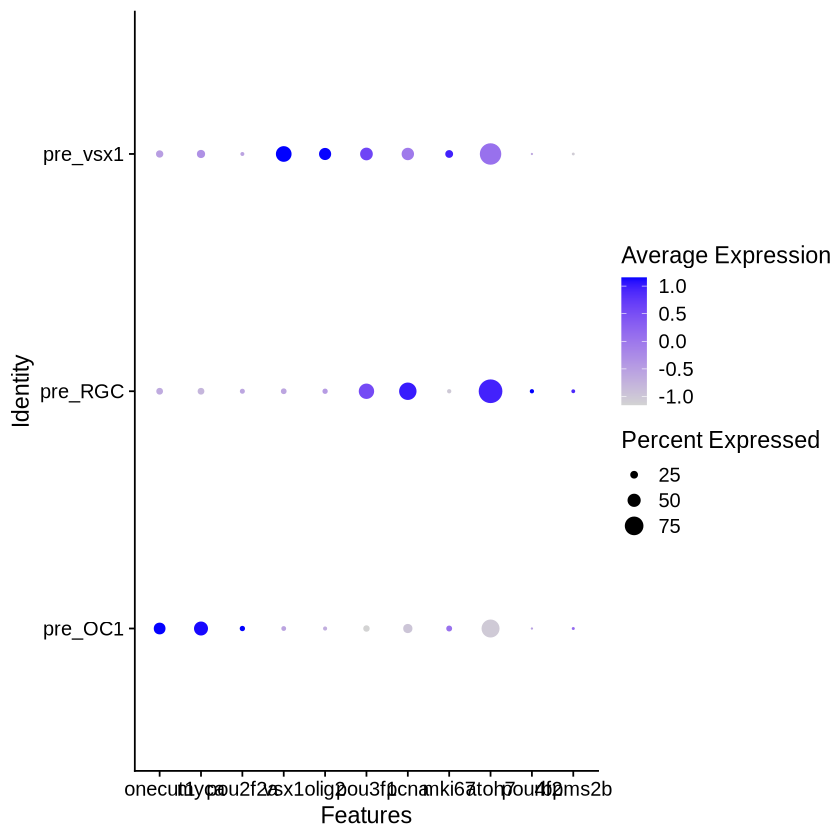

In [14]:
# check marker genes expression, replication of Figure S6D
DotPlot(precursor, features = c("onecut1", "myca", "pou2f2a", "vsx1", "olig2", "pou3f1", "pcna", "mki67", "atoh7", "pou4f2", "rbpms2b"))

# reanalyze AC

In [15]:
# reanalyze AC
AC <- subset(AA, idents = c("AC"))
AC <- NormalizeData(AC)
AC <- FindVariableFeatures(AC, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(AC)
AC <- ScaleData(AC, features = all.genes)
AC <- RunPCA(AC, features = VariableFeatures(object = AC))
AC <- FindNeighbors(AC, dims = 1:6)
AC <- FindClusters(AC, resolution = 0.5)
AC<- RunUMAP(AC, dims = 1:6)

Centering and scaling data matrix

PC_ 1 
Positive:  zgc:110540, esco2, snap25b, asf1ba, pclaf, slc29a2, adssl, mibp, elavl3, gng3 
	   CR361564.1, krcp, banf1, pcbp3, gapdhs, rrm2.1, stmn1a, rem1, rnaseh2a, pde6gb 
	   btg3, tmsb4x, mtss1lb, stmn1b, uhrf1, chaf1a, tyms, pcna, si:ch211-156b7.4, asf1bb 
Negative:  mdka, her15.2, her15.1, abhd6a, ptf1a, ptprua, pou3f1, CR848047.1, si:ch73-215f7.1, si:ch211-207i1.2 
	   s1pr1, hes6, lfng, tanc2a, hmgn2, tfap2c, scrt2, im:7152348, CU467822.1, ndrg1b 
	   her4.2.1, tfdp2, lzts2a, prickle1b, lrrn1, her4.1, her4.2, neurod4, fabp7a, hey1 
PC_ 2 
Positive:  zgc:110540, esco2, pde6gb, dut, asf1ba, slc29a2, krcp, rpa3, rrm2.1, hmgb2a 
	   mibp, pcna, btg3, tyms, uhrf1, rnaseh2a, stmn1a, hmgn2, haus4, pclaf 
	   CR361564.1, asf1bb, rrm1, dtymk, rem1, chaf1a, fen1, dhfr, rfc5, aurkb 
Negative:  elavl3, pax10, celf5a, hmgb3a, myt1b, nrxn3a, fscn1a, gad2, meis2a, sox4a.1 
	   eif4ebp1, tfap2a, lhx9, ywhah, meis2a.1, mab21l2, zc4h2, mapk10, h2afx1, ac

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 513
Number of edges: 13216

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8038
Number of communities: 7
Elapsed time: 0 seconds


16:18:11 UMAP embedding parameters a = 0.9922 b = 1.112

16:18:11 Read 513 rows and found 6 numeric columns

16:18:11 Using Annoy for neighbor search, n_neighbors = 30

16:18:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:18:11 Writing NN index file to temp file /tmp/RtmpmJ67V6/file4c48f5d896e5a

16:18:11 Searching Annoy index using 1 thread, search_k = 3000

16:18:11 Annoy recall = 100%

16:18:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:18:12 Initializing from normalized Laplacian + noise (using RSpectra)

16:18:12 Commencing optimization for 500 epochs, with 17606 positive edges

16:18:14 Optimization finished



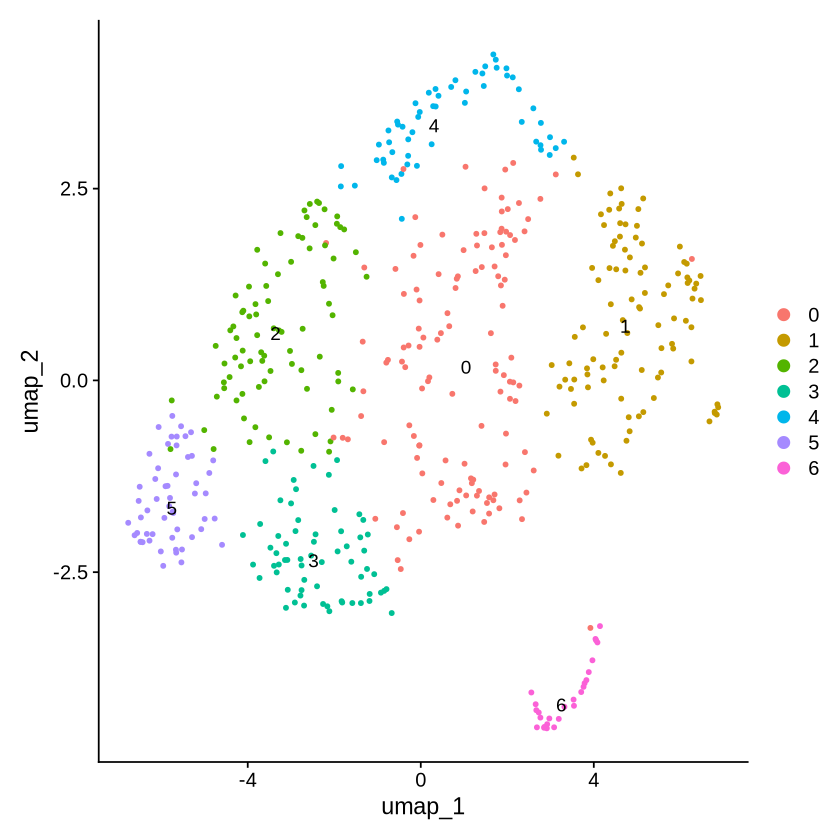

In [16]:
DimPlot(AC, reduction = "umap", label = TRUE)

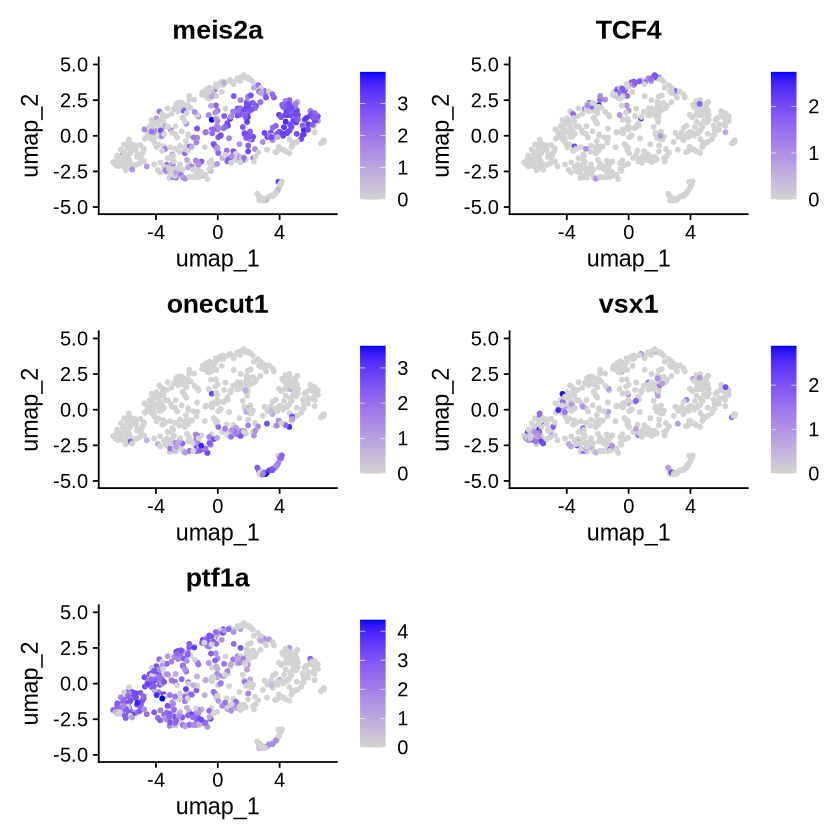

In [17]:

FeaturePlot(AC, features = c("meis2a" ,"TCF4", "onecut1", "vsx1", "ptf1a"))

Warning message:
“Cannot find identity 7”


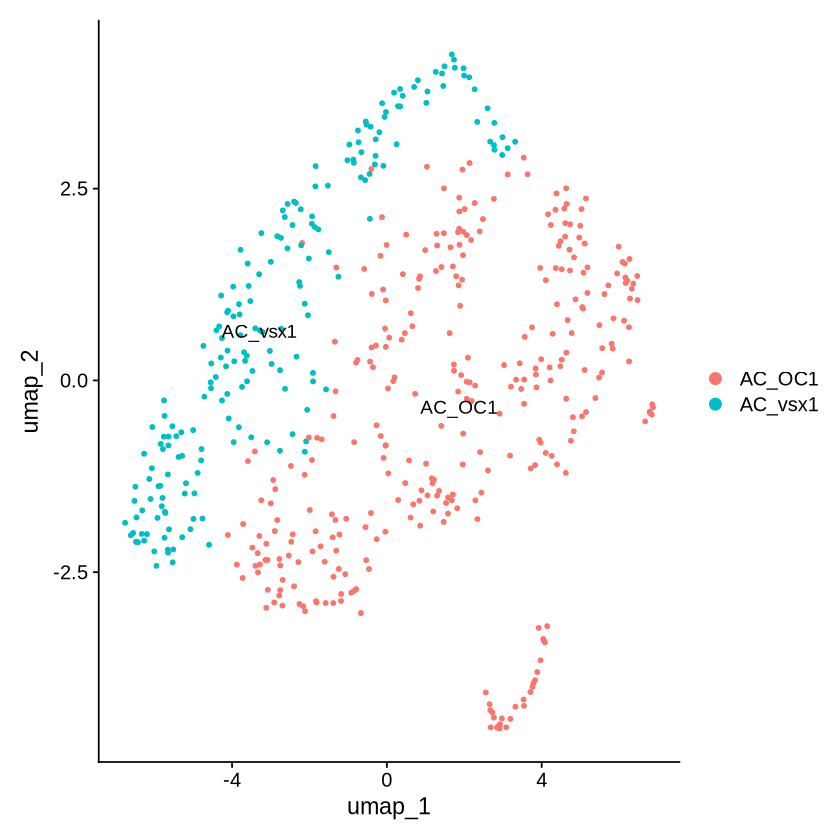

In [18]:
## annotation
AC <- RenameIdents(AC, "0" = "AC_OC1", "1" = "AC_OC1", "2" = "AC_vsx1", "3" = "AC_OC1", "4" = "AC_vsx1", "5"  = "AC_vsx1", "6" = "AC_OC1", "7" = "AC_OC1")
DimPlot(AC, reduction = "umap", label = TRUE)

# replication of Figure S6E

Warning message:
“Scaling data with a low number of groups may produce misleading results”


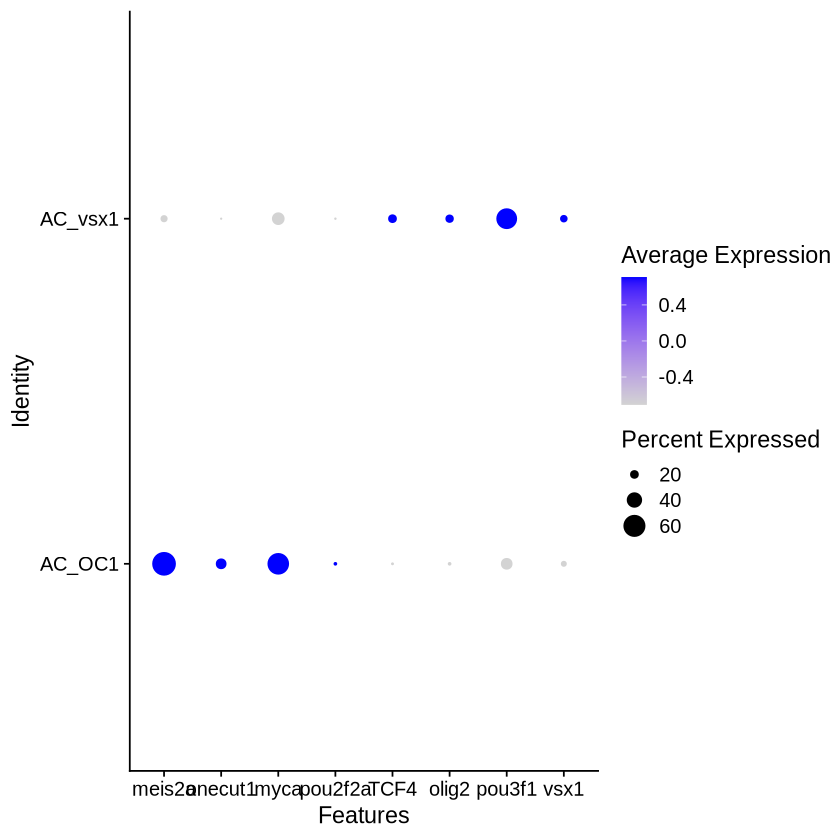

In [19]:
## check marker genes expression, replication of Figure S6E
DotPlot(AC, features = c("meis2a", "onecut1", "myca", "pou2f2a", "TCF4", "olig2", "pou3f1", "vsx1"))

# reanalyze progenitor cells

In [20]:
# reanalyze progenitor cells
progenitor <- subset(AA, idents = c ("pro"))
progenitor <- NormalizeData(progenitor)
progenitor <- FindVariableFeatures(progenitor, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(progenitor)
progenitor <- ScaleData(progenitor, features = all.genes)
progenitor <- RunPCA(progenitor, features = VariableFeatures(object = progenitor))
# clustering
progenitor <- FindNeighbors(progenitor, dims = 2:10)
progenitor <- FindClusters(progenitor, resolution = 0.5)
progenitor <- RunUMAP(progenitor, dims = 2:10)

Centering and scaling data matrix

PC_ 1 
Positive:  nusap1, si:ch211-69g19.2, ube2c, plk1, kif11, tpx2, tubb4b, cdc20, cdk1, ccnb3 
	   kpna2, aspm, top2a, birc5a, pif1, cenpf, g2e3, kifc1, ccnb1, mad2l1 
	   mki67, prc1a, pcdh17, aurka, tacc3, cdc14b, arl6ip1, CABZ01058261.1, cdca8, dlgap5 
Negative:  pcna, rpa2, rpa3, fen1, slbp, lig1, dut, rpa1, dnajc9, mcm2 
	   mcm4, rfc2, rfc4, nasp, her4.1, mcm6, her4.2, her12, mcm5, pole4 
	   cdc6, mcm3, pclaf, mcm7, rrm2.1, zgc:110540, esco2, hells, her4.2.1, asf1bb 
PC_ 2 
Positive:  stmn1a, pou2f2a.1, si:ch211-222l21.1, rbpjb, atoh7, onecut1, neurod4, rrm2.1, cdkn1ca, inhbb 
	   insm1a, zic2b, mibp, pcna, dut, bhlhe22, dhfr, pclaf, onecut2, dck 
	   rpa3, hirip3, fthl27, rpa2, pax6a, zgc:110540, rrs1, tbx2b, lig1, krcp 
Negative:  si:dkey-238o13.4, acbd7, BX465834.1, cldn5b, her8a, ckbb, notch3, her12, lfng, cd82a 
	   tjp2b, prox1a, fabp7a, CU467822.1, id1, sb:cb81, cspg5a, marcksl1b, emilin1a, lhx9 
	   akap12b, crabp1a, hsd11b2, mdka, s

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 880
Number of edges: 27361

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7889
Number of communities: 7
Elapsed time: 0 seconds


16:18:18 UMAP embedding parameters a = 0.9922 b = 1.112

16:18:18 Read 880 rows and found 9 numeric columns

16:18:18 Using Annoy for neighbor search, n_neighbors = 30

16:18:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:18:18 Writing NN index file to temp file /tmp/RtmpmJ67V6/file4c48f1b772971

16:18:18 Searching Annoy index using 1 thread, search_k = 3000

16:18:18 Annoy recall = 100%

16:18:19 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:18:19 Initializing from normalized Laplacian + noise (using RSpectra)

16:18:19 Commencing optimization for 500 epochs, with 32386 positive edges

16:18:22 Optimization finished



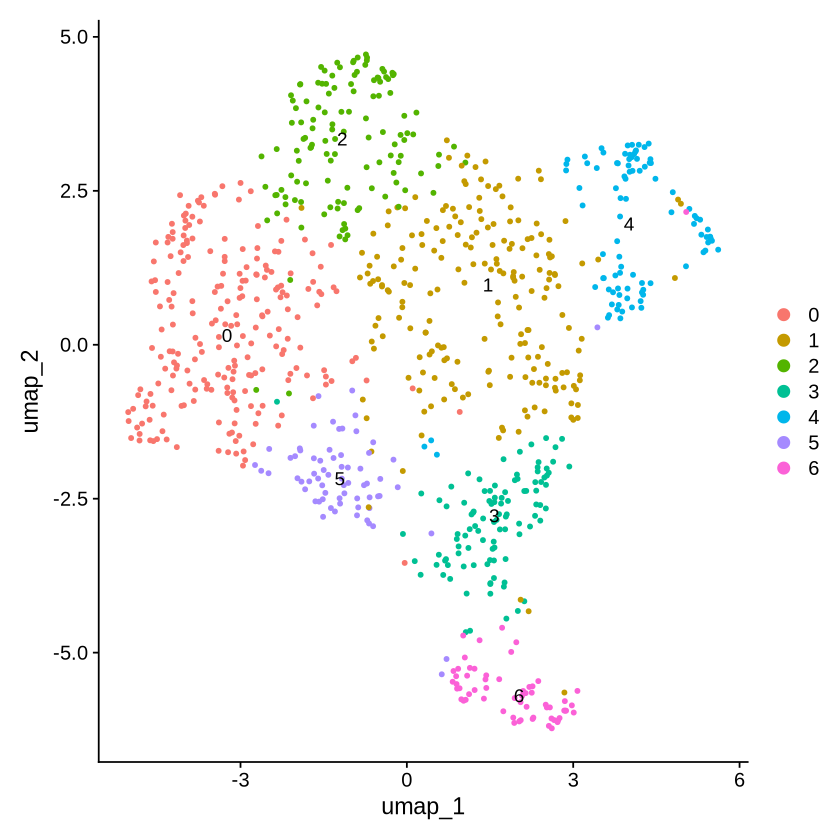

In [21]:
DimPlot(progenitor, reduction = "umap", label = TRUE)

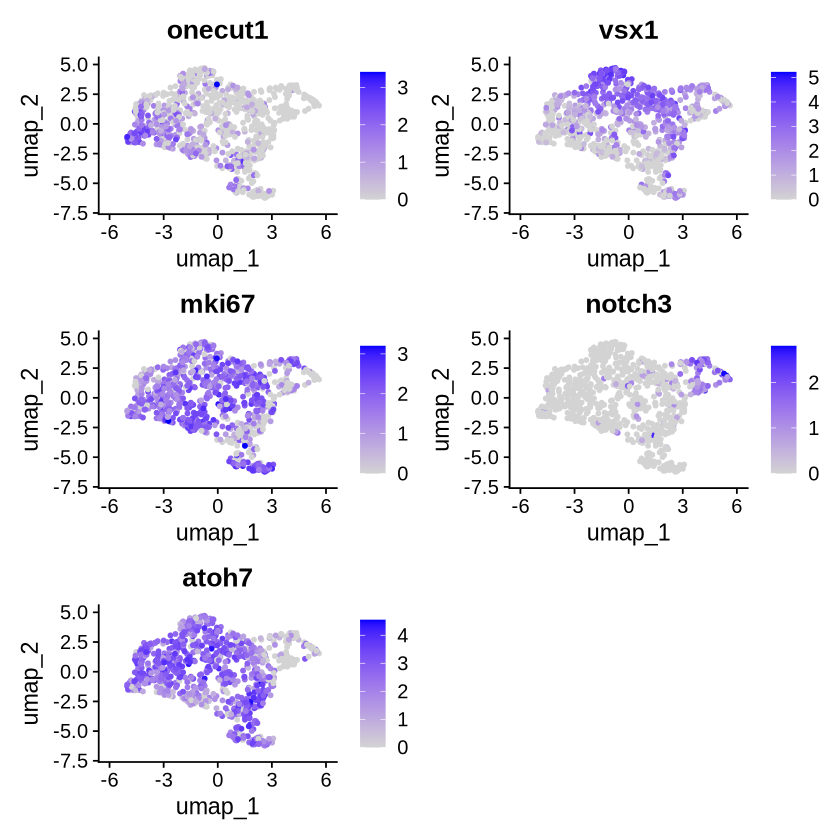

In [22]:
FeaturePlot(progenitor, features = c("onecut1",   "vsx1",  "mki67", "notch3", "atoh7"))

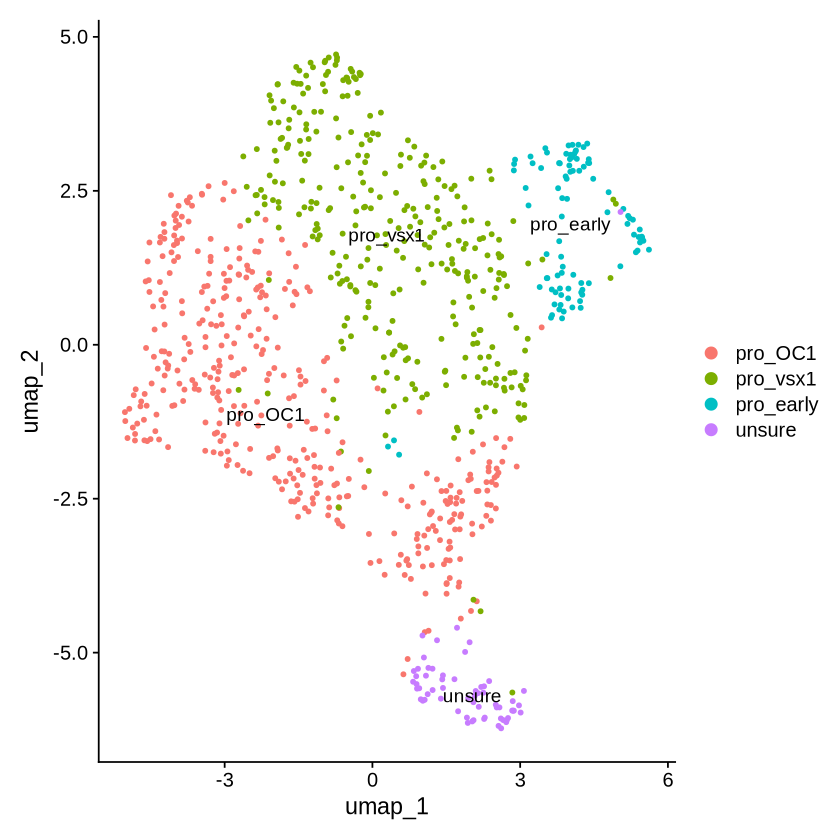

In [23]:
progenitor <- RenameIdents(progenitor, "0" = "pro_OC1", "1" = "pro_vsx1", "2" = "pro_vsx1", "3" = "pro_OC1", "4" = "pro_early", "5"  = "pro_OC1", "6" = "unsure")
DimPlot(progenitor, reduction = "umap", label = TRUE)

# replication of Figure S6C

Warning message:
“Scaling data with a low number of groups may produce misleading results”


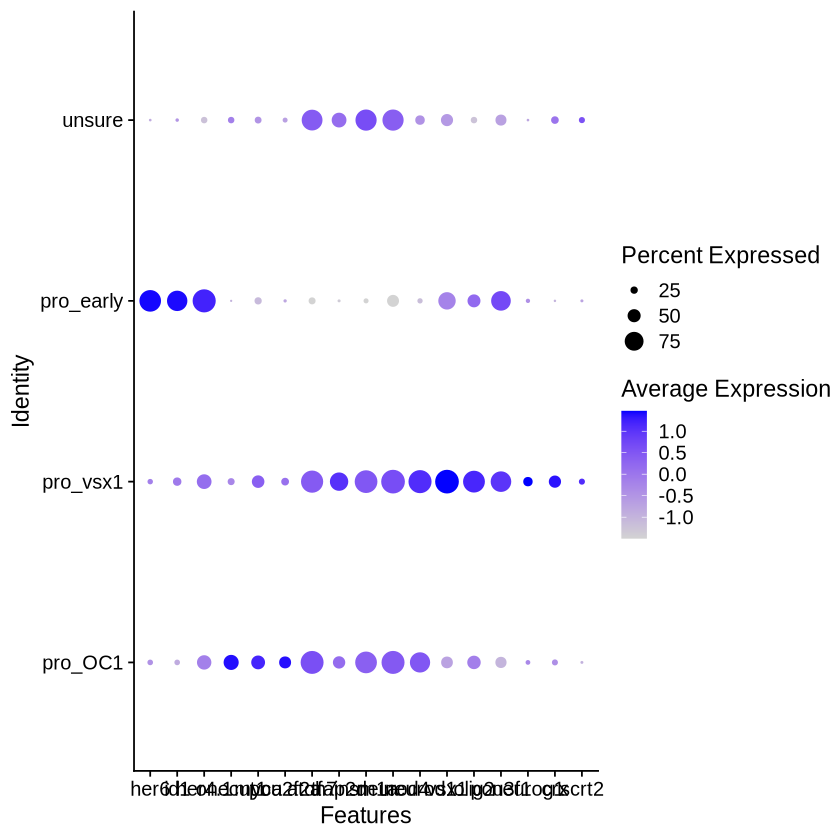

In [24]:
## check marker genes expression, replication of Figure S6C
DotPlot(progenitor, features = c("her6", "id1", "her4.1", "onecut1", "myca", "pou2f2a", "atoh7", "tfap2d", "insm1a", "neurod4", "neurod1", "vsx1", "olig2", "pou3f1", "neurog1", "crx", "scrt2"))

# reanalyze vsx1 lineage (AC-BC lineage)

In [25]:
# reanalyze vsx1 lineage (AC-BC lineage)
## extract vsx1 lineage cells
pro_vsx1_names <- names(Idents(progenitor)[Idents(progenitor) == "pro_vsx1"])
pre_vsx1_names <- names(Idents(precursor)[Idents(precursor) == "pre_vsx1"])
AC_vsx1_names <- names(Idents(AC)[Idents(AC) ==  "AC_vsx1"])
BC_vsx1_names <- names(Idents(AA)[Idents(AA) == "BC"])
cell_names_to_keep <- c(pro_vsx1_names, pre_vsx1_names, AC_vsx1_names, BC_vsx1_names)
vsx1 <- subset(AA, cells = cell_names_to_keep)
vsx1

An object of class Seurat 
18835 features across 951 samples within 1 assay 
Active assay: RNA (18835 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

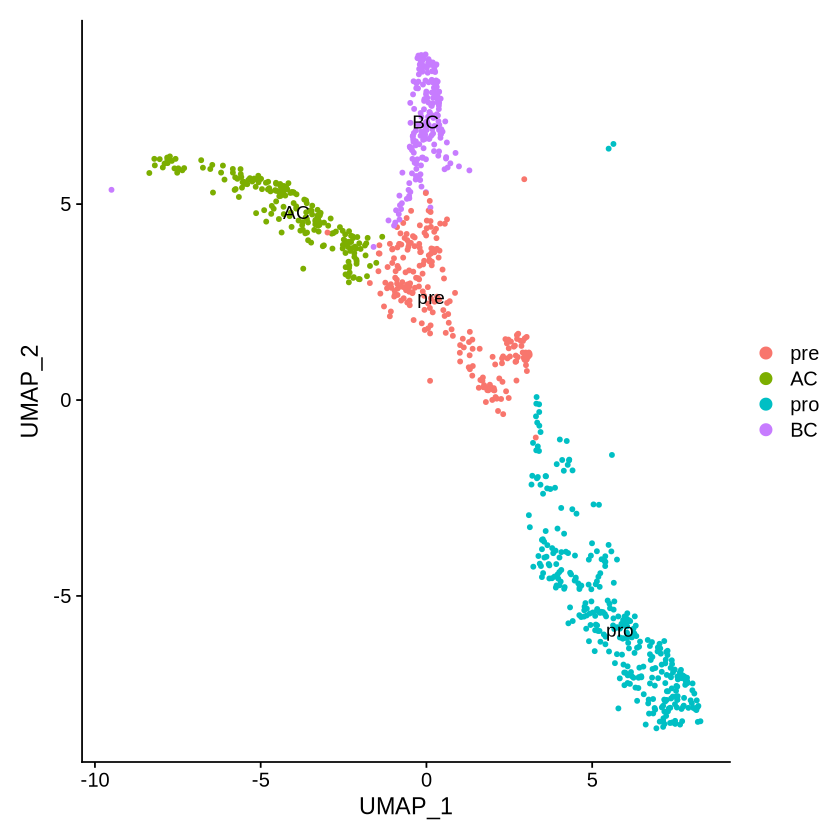

In [26]:
DimPlot(vsx1, reduction = "umap", label = TRUE)

In [27]:
## pre-processing
vsx1 <- NormalizeData(vsx1)
vsx1 <- FindVariableFeatures(vsx1, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(vsx1)
vsx1 <- ScaleData(vsx1, features = all.genes)
vsx1 <- RunPCA(vsx1, features = VariableFeatures(object = vsx1))

Centering and scaling data matrix

PC_ 1 
Positive:  ppdpfb, fabp3, scrt2, dscaml1, tmem178b, otx5, fkbp1ab, ckbb, ppp1r14c, tp53inp1 
	   daam1a, pcbp3, s1pr1, samsn1a, fhod3b, ndrg4, hsp70.1, hsp70l, scg3, ppdpfa 
	   SEMA4F, syt5b, h2afx1, bhlhe23, igsf21a, stxbp1b, grid2, sgip1a, pcdh10a, sesn1 
Negative:  ccna2, mad2l1, nusap1, cdk1, mki67, lbr, plk1, top2a, tuba8l, aurkb 
	   h3f3a, foxn4, tuba8l4, ube2c, kifc1, CABZ01058261.1, tpx2, zgc:165555.11, cks1b, kif11 
	   kif22, hmgb2a, dlgap5, tubb4b, cdc20, tubb2b, msna, si:ch211-69g19.2, cdca8, calm2b 
PC_ 2 
Positive:  pcna, hmgb2b, cirbpa, abhd6a, her4.2, her15.1, her15.2, her4.1, her4.2.1, fabp7a 
	   fen1, si:ch211-222l21.1, rpa2, hmgn2, lig1, rpa3, seta, mcm2, dut, mcm6 
	   pax6a, her4.4, rpa1, mcm4, her12, slbp, mcm3, mcm5, CR848047.1, dnajc9 
Negative:  samsn1a, vsx1, syt5b, daam1a, pcdh17, fhod3b, bhlhe23, igsf21a, fezf2, otx5 
	   stxbp1b, ndrg1b, SEMA4F, ctnna2, dscaml1, grid2, ddah2, si:ch211-69g19.2, kpna2, sgip1a 
	   

In [28]:
## clustering
vsx1 <- FindNeighbors(vsx1, dims = 1:10)
vsx1 <- FindClusters(vsx1, resolution = 0.5)
vsx1 <- RunUMAP(vsx1, dims = 1:10)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 951
Number of edges: 26615

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8642
Number of communities: 7
Elapsed time: 0 seconds


16:18:27 UMAP embedding parameters a = 0.9922 b = 1.112

16:18:27 Read 951 rows and found 10 numeric columns

16:18:27 Using Annoy for neighbor search, n_neighbors = 30

16:18:27 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:18:27 Writing NN index file to temp file /tmp/RtmpmJ67V6/file4c48f29ea9c0

16:18:27 Searching Annoy index using 1 thread, search_k = 3000

16:18:27 Annoy recall = 100%

16:18:27 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:18:28 Initializing from normalized Laplacian + noise (using RSpectra)

16:18:28 Commencing optimization for 500 epochs, with 34818 positive edges

16:18:31 Optimization finished



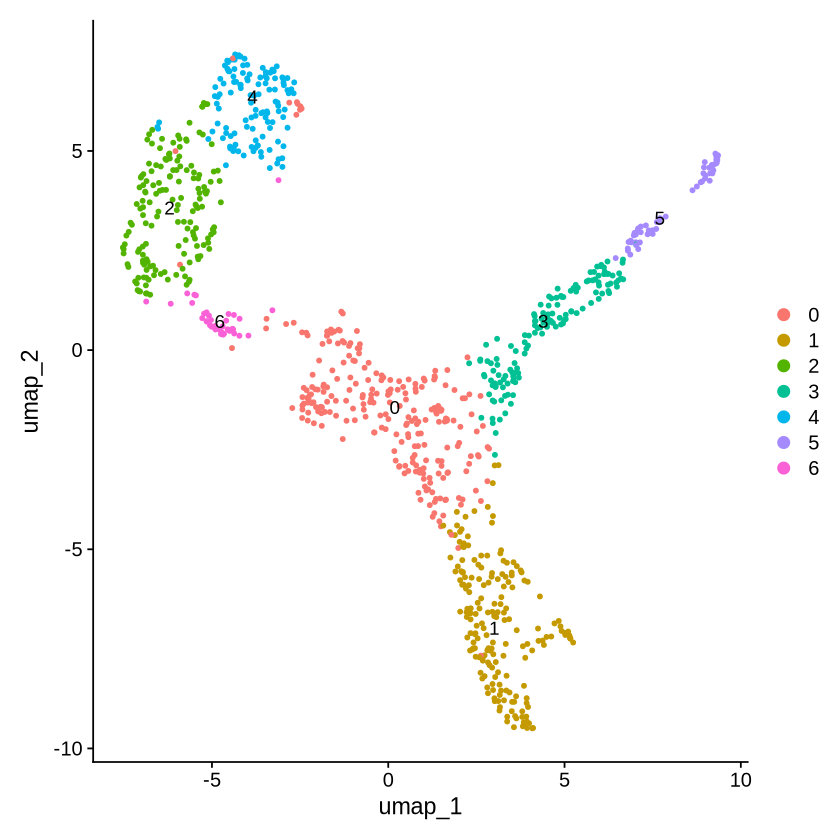

In [29]:
DimPlot(vsx1, reduction = "umap", label = TRUE)

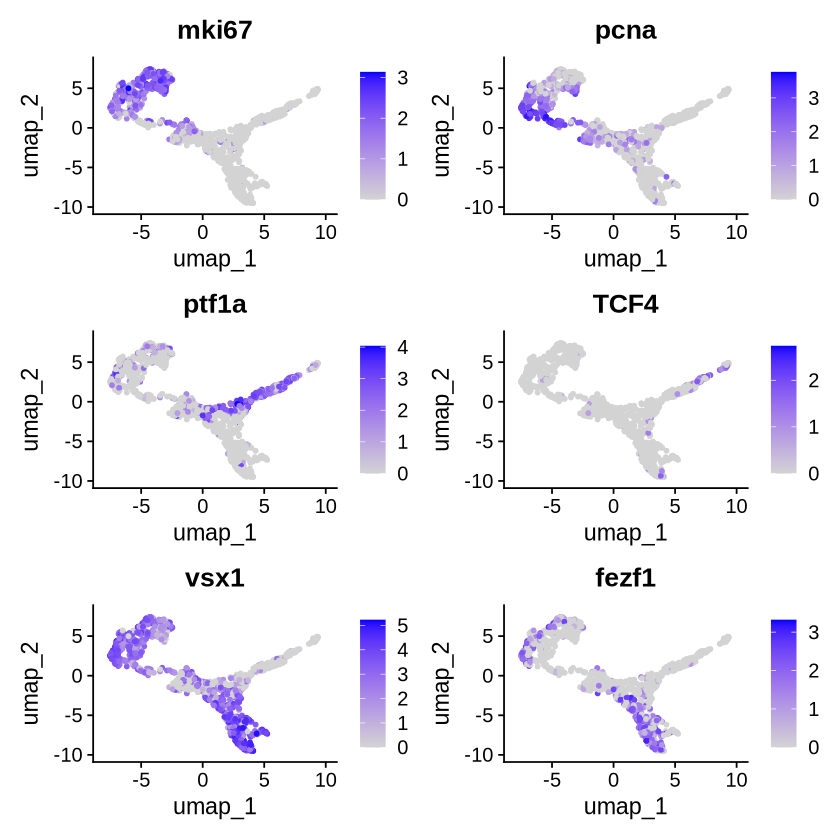

In [30]:
FeaturePlot(vsx1, features = c("mki67" ,"pcna", "ptf1a", "TCF4", "vsx1", "fezf1"))

## replication of Figure S6F

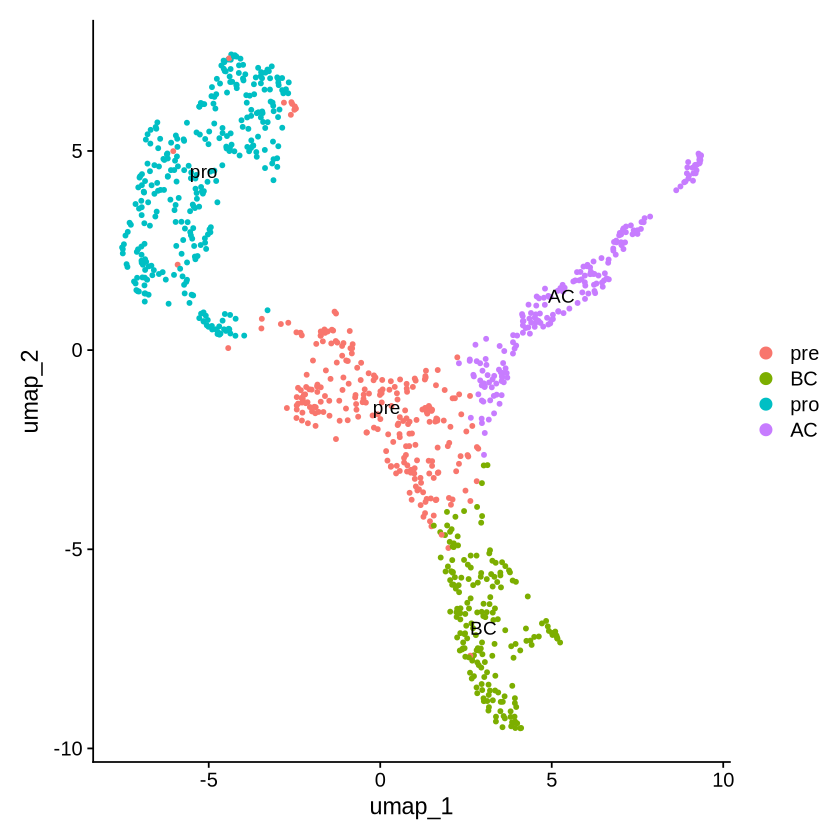

In [31]:
## annotate clusters, replication of Figure 6F
acbc <- RenameIdents(vsx1, "0" = "pre", "1" = "BC", "2" = "pro", "3" = "AC", "4" = "pro", "5"= "AC", "6" = "pro")
DimPlot(acbc, reduction = "umap", label = TRUE)

In [32]:
saveRDS(acbc, "acbc_rna.rds")

## replication of Figure 6G

Warning message:
“Scaling data with a low number of groups may produce misleading results”


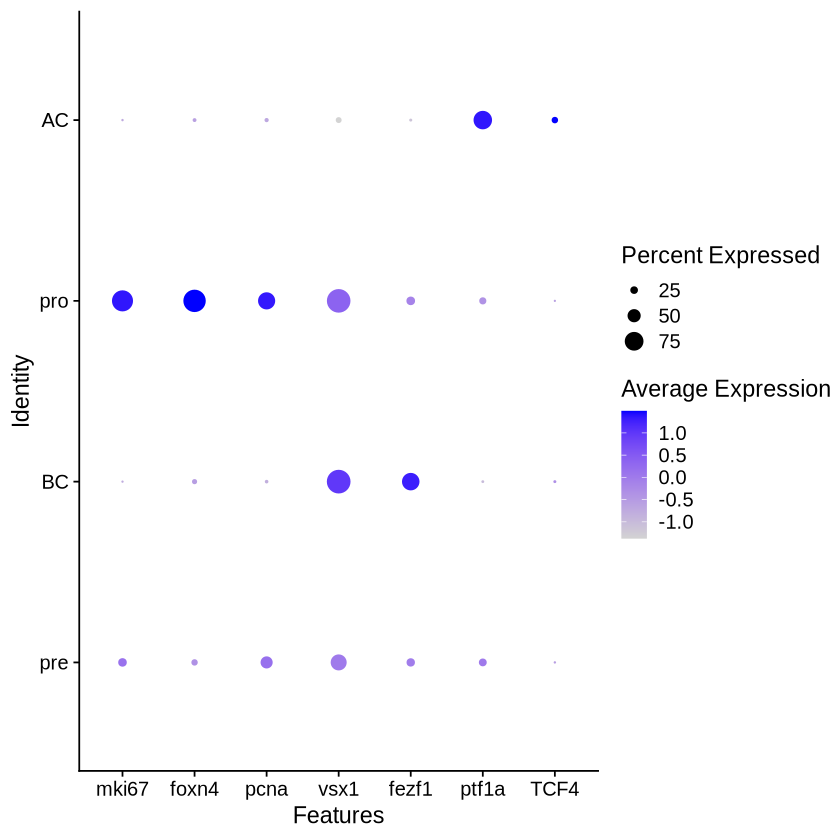

In [33]:
## marker gene expression in different states of AC-BC lineages, replication of Figure 6G
DotPlot(acbc, features = c("mki67", "foxn4", "pcna",  "vsx1",  "fezf1", "ptf1a", "TCF4"))

# Notch gene expression in AC-BC lineages

## replication of Figure 5A

Warning message:
“Scaling data with a low number of groups may produce misleading results”


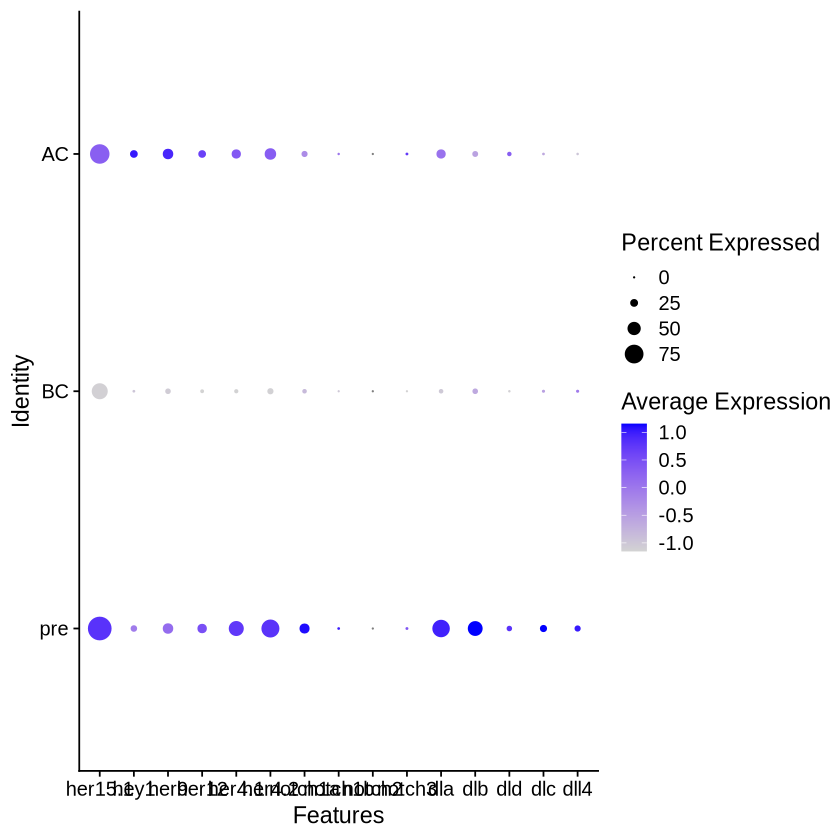

In [34]:
# Notch gene expression in AC-BC lineages, replication of Figure 5A
desired_cells <- subset(acbc, idents = c( "pre", "AC", "BC"))
notch.gene <- c( "her15.1", "hey1", "her9",  "her12", "her4.1", "her4.2", "notch1a", "notch1b", "notch2", "notch3",  "dla", "dlb",  "dld",  "dlc", "dll4")
DotPlot(desired_cells, features = notch.gene)

## calculate the average expression of Notch genes in different clusters

In [35]:
## calculate the average expression of Notch genes in different clusters
norm.expr <- AverageExpression(desired_cells, features = notch.gene)$RNA
head(norm.expr)


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


6 x 3 sparse Matrix of class "dgCMatrix"
               pre          BC        AC
her15.1 60.9640196 16.53801204 43.391557
hey1     0.5785971  0.06799521  1.508154
her9     1.5549856  0.79527586  2.224195
her12    2.2694896  0.21799286  2.598519
her4.1   5.5913915  0.24416405  3.740869
her4.2  20.9242788  0.94251508 10.973961

In [36]:
norm.expr <- cbind(norm.expr, norm.expr[,3] / (norm.expr[,2]+0.5))
norm.expr <- norm.expr[order(norm.expr[,4], decreasing = TRUE),]
norm.expr

15 x 4 sparse Matrix of class "dgCMatrix"
                pre          BC          AC           
her4.2  20.92427879  0.94251508 10.97396105 7.60751913
her4.1   5.59139152  0.24416405  3.74086865 5.02694080
her12    2.26948956  0.21799286  2.59851881 3.61914296
hey1     0.57859714  0.06799521  1.50815435 2.65522371
her15.1 60.96401960 16.53801204 43.39155737 2.54675001
dla      4.67117180  0.30125549  1.89955967 2.37072905
her9     1.55498556  0.79527586  2.22419518 1.71715945
dld      0.45481211  0.02769601  0.33218198 0.62949497
notch1a  1.00654574  0.29931860  0.47789251 0.59787487
dlb      2.54817052  0.39347044  0.45888051 0.51359339
notch3   0.05812653  .           0.06972851 0.13945702
dlc      0.76863309  0.08289365  0.04828020 0.08282848
notch1b  0.06387263  .           0.03233916 0.06467832
dll4     0.34469269  0.16179241  0.02404686 0.03633595
notch2   .           .           .          .         

# environment

In [37]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/wangmei/anaconda3/envs/seurat5/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] Seurat_5.1.0       SeuratObject_5.0.2 sp_2.1-4           dplyr_1.1.4       

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-2          gridExtra_2.3         
  [4] rlang_1.1.4    

In [38]:
sessioninfo::session_info(to_file = "session_acbc_rna.md")